In [1]:
from collections import Counter
from itertools import combinations
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from datetime import datetime
from Bio import SeqIO
from Bio.Seq import Seq

from Bio import SeqIO, Phylo
from Bio.SeqRecord import SeqRecord
import subprocess
import re

from Levenshtein import distance as lev_distance 

from dnsmex.local import localify
from netam.sequences import translate_sequence, AA_STR_SORTED
from utils import sort_antibody_sites


figures_dir = localify("FIGURES_DIR")

### Create IMGT and Chothia reference files
Create germline codon tables for IMGT and Chothia numbering schemes.

This script downloads OGRDB germline sequences and creates codon-level dataframes
with site numbering for both IMGT and Chothia schemes.

Purpose:

We need germline annotation files for:
- In current analysis repo:
    - Add germline annotation per site (is_germline_codon/aa)
    - Annotate sites for out of frame data - ANARCI cannot be used to number these
      sequences, so for the V gene area (until CDR3) for sequences that have no
      frameshifts (filtered for earlier), we can use the germline annotation files
      to annotate the sequences according to PARTIS v gene identification
- Later this can be used for pcp generation files (pcp-pipeline) with Chothia-based
  CDRs start and end sites.

Approach:

IMGT gapped files can be downloaded from the OGRDB website.
There is no such resource for Chothia.
We create Chothia numbering with ANARCI:
- Download the ungapped version from OGRDB website
- Filter for IGHV
- Run in ANARCI with human and heavy chain parameters
- Note: Chothia uses insertion codes (e.g., 52A, 52B) while IMGT is just int-based
  for IGHV gene area

Output files:

- germline/germline_codons_imgt.csv: IMGT numbering scheme
- germline/germline_codons_chothia.csv: Chothia numbering scheme


For this analysis, we use the OGRDB reference files. 
The reference files used by partis also come from this dataset, so the two are directly comparable. The key difference is that we download the gapped version of the OGRDB references, because the gaps preserve IMGT numbering. We also compared the gene IDs and they are the same. Thus we can use the OGRDB reference to annotate the files classified by partis.

In this analysis
- We create reference files that we can later merge onto sitewise dataframes to add gemrline annotations per v gene.
- We calculate the similarities between the different v genes and plot that.

In [13]:
## create the germline codon tables for IMGT and Chothia schemes
! cd /home/nharel/re/dasm-epistasis-experiments && source ~/.bashrc && conda activate netam_env && python create_germline_codon_tables.py

LIBCIFPP_DATA_DIR has been unset
LIBCIFPP_DATA_DIR has been set to: /home/nharel/miniforge3/envs/netam_env/share/libcifpp
Creating Germline Codon Tables

### Step 1: Downloading OGRDB files ###
Gapped FASTA downloaded successfully as germline/ogrdb_human_IGH_gapped.fasta
Ungapped FASTA file germline/ogrdb_human_IGH_ungapped.fasta already exists. Skipping download.

### Step 2: Creating IMGT codon table ###

=== Creating IMGT codon table ===
Verifying that gaps are codon-aligned...
✓ All gaps are codon-aligned (3 nucleotides per codon)
Loaded 198 IGHV sequences
Removing 6 genes with stop codons
IMGT codon table saved: germline/germline_codons_imgt.csv
  Rows: 18857
  Unique genes: 192

### Step 3: Preparing files for Chothia numbering ###
Filtering IGHV sequences from germline/ogrdb_human_IGH_ungapped.fasta...
Filtered 198 IGHV sequences saved to germline/ogrdb_human_IGH_ungapped_ighv.fasta
Translating sequences to amino acids...
Translated 198 sequences saved to germline/ogrdb_human_IG

In [15]:
# test simialrities and differences between IMGT and Chothia germline codon tables

# Load both germline codon tables
imgt_codons = pd.read_csv(localify(f"germline/germline_codons_imgt.csv"))
chothia_codons = pd.read_csv(localify(f"germline/germline_codons_chothia.csv"))

print("=" * 80)
print("IMGT vs Chothia Germline Codon Tables Comparison")
print("=" * 80)

# Test 1: Basic statistics
print("\n=== Test 1: Basic Statistics ===")
print(f"IMGT table:")
print(f"  Rows: {len(imgt_codons):,}")
print(f"  Unique genes: {imgt_codons['v_gene'].nunique()}")
print(f"  Unique sites: {imgt_codons['site'].nunique()}")
print(f"  Site range: {imgt_codons['site'].min()} - {imgt_codons['site'].max()}")

print(f"\nChothia table:")
print(f"  Rows: {len(chothia_codons):,}")
print(f"  Unique genes: {chothia_codons['v_gene'].nunique()}")
print(f"  Unique sites: {chothia_codons['site'].nunique()}")
print(f"  Site range: {chothia_codons['site'].min()} - {chothia_codons['site'].max()}")

# Test 2: Gene overlap
print("\n=== Test 2: Gene Overlap ===")
imgt_genes = set(imgt_codons['v_gene'].unique())
chothia_genes = set(chothia_codons['v_gene'].unique())

genes_in_both = imgt_genes & chothia_genes
genes_only_imgt = imgt_genes - chothia_genes
genes_only_chothia = chothia_genes - imgt_genes

print(f"Genes in both schemes: {len(genes_in_both)}")
print(f"Genes only in IMGT: {len(genes_only_imgt)}")
if genes_only_imgt:
    print(f"  Examples: {list(genes_only_imgt)[:5]}")
print(f"Genes only in Chothia: {len(genes_only_chothia)}")
if genes_only_chothia:
    print(f"  Examples: {list(genes_only_chothia)[:5]}")

# Test 3: Site numbering differences
print("\n=== Test 3: Site Numbering Schemes ===")
print(f"IMGT sites (first 20): {sorted(imgt_codons['site'].unique())[:20]}")
print(f"Chothia sites (first 20): {sorted(chothia_codons['site'].unique())[:20]}")

# Check if Chothia has insertion codes (like 52A, 52B)
chothia_sites_with_letters = [s for s in chothia_codons['site'].unique() if any(c.isalpha() for c in str(s))]
print(f"\nChothia sites with insertion codes: {len(chothia_sites_with_letters)}")
if chothia_sites_with_letters:
    print(f"  Examples: {sorted(chothia_sites_with_letters)[:10]}")

# Test 4: Sequence alignment for shared genes
print("\n=== Test 4: Sequence Comparison for Shared Genes ===")

# Pick a gene that exists in both schemes
test_gene = list(genes_in_both)[0]
print(f"Testing with gene: {test_gene}")

imgt_gene_data = imgt_codons[imgt_codons['v_gene'] == test_gene].sort_values('site')
chothia_gene_data = chothia_codons[chothia_codons['v_gene'] == test_gene].sort_values('site')

print(f"\nIMGT sites for {test_gene}: {len(imgt_gene_data)} positions")
print(f"Chothia sites for {test_gene}: {len(chothia_gene_data)} positions")

# Compare sequences (should be identical, just numbered differently)
imgt_seq = ''.join(imgt_gene_data['amino_acid'].values)
chothia_seq = ''.join(chothia_gene_data['amino_acid'].values)

print(f"\nIMGT sequence length: {len(imgt_seq)} aa")
print(f"Chothia sequence length: {len(chothia_seq)} aa")

# Compare the overlap
min_len = min(len(imgt_seq), len(chothia_seq))
if min_len > 0:
    matches = sum(1 for i in range(min_len) if imgt_seq[i] == chothia_seq[i])
    print(f"Sequence identity (first {min_len} positions): {matches/min_len*100:.1f}%")

# Test 5: Position counts per gene
print("\n=== Test 5: Position Counts Per Gene ===")

imgt_positions_per_gene = imgt_codons.groupby('v_gene')['site'].count()
chothia_positions_per_gene = chothia_codons.groupby('v_gene')['site'].count()

print(f"IMGT - Average positions per gene: {imgt_positions_per_gene.mean():.1f}")
print(f"Chothia - Average positions per gene: {chothia_positions_per_gene.mean():.1f}")

# For shared genes, compare position counts
shared_gene_comparison = pd.DataFrame({
    'imgt_positions': imgt_positions_per_gene,
    'chothia_positions': chothia_positions_per_gene
}).dropna()

print(f"\nFor {len(shared_gene_comparison)} shared genes:")
print(f"  Average IMGT positions: {shared_gene_comparison['imgt_positions'].mean():.1f}")
print(f"  Average Chothia positions: {shared_gene_comparison['chothia_positions'].mean():.1f}")
print(f"  Genes with different position counts: {(shared_gene_comparison['imgt_positions'] != shared_gene_comparison['chothia_positions']).sum()}")

# Show some examples of genes with different position counts
different_counts = shared_gene_comparison[shared_gene_comparison['imgt_positions'] != shared_gene_comparison['chothia_positions']]
if len(different_counts) > 0:
    print(f"\nExamples of genes with different position counts:")
    print(different_counts.head(10))

# Test 6: Amino acid and codon distributions
print("\n=== Test 6: Amino Acid and Codon Distributions ===")

imgt_aa_counts = imgt_codons['amino_acid'].value_counts()
chothia_aa_counts = chothia_codons['amino_acid'].value_counts()

print(f"IMGT - Most common amino acids:")
print(imgt_aa_counts.head(5))

print(f"\nChothia - Most common amino acids:")
print(chothia_aa_counts.head(5))

# Test 7: V family distribution
print("\n=== Test 7: V Family Distribution ===")

imgt_family_counts = imgt_codons.groupby('v_family')['v_gene'].nunique()
chothia_family_counts = chothia_codons.groupby('v_family')['v_gene'].nunique()

print(f"IMGT families:")
print(imgt_family_counts.sort_index())

print(f"\nChothia families:")
print(chothia_family_counts.sort_index())

print("\n" + "=" * 80)
print("Summary:")
print("- Both tables cover overlapping but not identical gene sets")
print("- IMGT uses integer numbering, Chothia uses insertion codes (e.g., 52A)")
print("- Chothia sequences end at position 94 (end of V domain)")
print("- IMGT sequences extend further into CDR3/junction region")
print("=" * 80)

IMGT vs Chothia Germline Codon Tables Comparison

=== Test 1: Basic Statistics ===
IMGT table:
  Rows: 18,857
  Unique genes: 192
  Unique sites: 103
  Site range: 1 - 107

Chothia table:
  Rows: 18,540
  Unique genes: 189
  Unique sites: 102
  Site range: 1 - 94

=== Test 2: Gene Overlap ===
Genes in both schemes: 189
Genes only in IMGT: 3
  Examples: ['IGHV8-51-1*05', 'IGHV8-51-1*02', 'IGHV8-51-1*04']
Genes only in Chothia: 0

=== Test 3: Site Numbering Schemes ===
IMGT sites (first 20): [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21)]
Chothia sites (first 20): ['1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27']

Chothia sites with insertion codes: 8
  Examples: ['31A', '31B', '52A', '52B', '52C', '

In [2]:
numbering_scheme = 'imgt'
numbering_scheme = 'chothia'
codons_df = pd.read_csv(localify(f"germline/germline_codons_{numbering_scheme}.csv"))

In [7]:
# calculate distance between v genes

def calculate_similarity(df, level="nucleotide", metric="hamming"):
    """
    Calculate pairwise similarity between v_genes using nucleotides or amino acids,
    with Hamming or Levenshtein distance. Missing codons are treated as gaps.
    
    Args:
        df : DataFrame with columns ['v_gene', 'site', 'codon']
        level : str, "nucleotide" or "aa"
        metric : str, "hamming" or "levenshtein"
        
    Returns:
        similarity_matrix : pandas DataFrame
    """
    
    # Pivot into codon matrix (missing codons remain NaN)
    codon_matrix = df.pivot(index='v_gene', columns='site', values='codon')
    
    if level == "aa":
        # Translate codons using Biopython
        def translate_codon(c):
            if pd.isnull(c):
                return '-'  # gap
            try:
                return str(Seq(c).translate(to_stop=False))
            except:
                return 'X'  # unknown codon
        
        matrix = codon_matrix.applymap(translate_codon)
        # Concatenate amino acids into sequences
        seqs = matrix.apply(lambda row: ''.join(row.values), axis=1)
        
    elif level == "nucleotide":
        # Split codons into individual nucleotides
        def split_codon(c):
            if pd.isnull(c):
                return ['-','-','-']  # gap for missing codon
            return list(c)
        
        # Expand each codon column into 3 nucleotide columns
        nuc_matrix = pd.DataFrame(index=codon_matrix.index)
        for col in codon_matrix.columns:
            split_cols = codon_matrix[col].apply(split_codon)
            nuc_matrix = pd.concat([nuc_matrix, pd.DataFrame(split_cols.tolist(),
                                                             index=codon_matrix.index,
                                                             columns=[f"{col}_1", f"{col}_2", f"{col}_3"])],
                                   axis=1)
        # Concatenate nucleotides into full sequences
        seqs = nuc_matrix.apply(lambda row: ''.join(row.values), axis=1)
    
    else:
        raise ValueError("level must be 'nucleotide' or 'aa'")
    
    # Initialize similarity matrix
    indices = seqs.index
    similarity_matrix = pd.DataFrame(index=indices, columns=indices, dtype=float)
    
    # Pairwise comparisons
    for gene1, gene2 in combinations(indices, 2):
        s1, s2 = seqs[gene1], seqs[gene2]
        
        if metric == "hamming":
            paired = [(a, b) for a, b in zip(s1, s2) if a != '-' and b != '-']
            if len(paired) == 0:
                similarity = np.nan
            else:
                identical = sum(a == b for a, b in paired)
                similarity = identical / len(paired)
        
        elif metric == "levenshtein":
            dist = lev_distance(s1, s2)
            max_len = max(len(s1), len(s2))
            similarity = 1 - (dist / max_len if max_len > 0 else 0.0)
        
        else:
            raise ValueError("metric must be 'hamming' or 'levenshtein'")
        
        similarity_matrix.loc[gene1, gene2] = similarity
        similarity_matrix.loc[gene2, gene1] = similarity
    
    # Self-similarity = 1
    np.fill_diagonal(similarity_matrix.values, 1.0)
    
    return similarity_matrix


distance_hamming_nucleotide = calculate_similarity(codons_df, level="nucleotide", metric="hamming")
distance_hamming_aa = calculate_similarity(codons_df, level="aa", metric="hamming")
distance_levenshtein_nucleotide = calculate_similarity(codons_df, level="nucleotide", metric="levenshtein")
distance_levenshtein_aa = calculate_similarity(codons_df, level="aa", metric="levenshtein")


/tmp/ipykernel_3160611/3400982594.py:30: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  matrix = codon_matrix.applymap(translate_codon)
/tmp/ipykernel_3160611/3400982594.py:30: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  matrix = codon_matrix.applymap(translate_codon)


/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


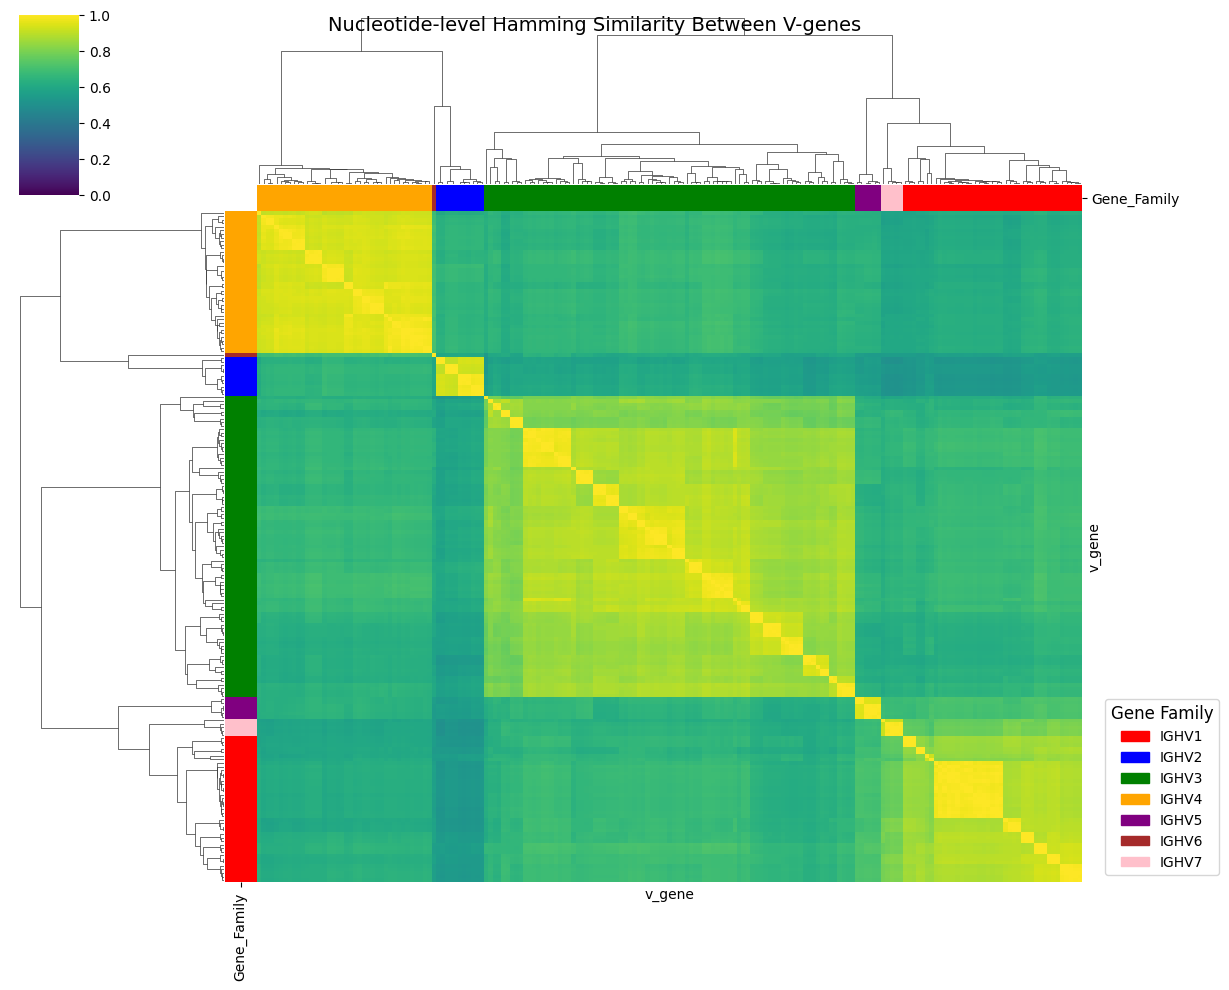

Gene family color mapping:
IGHV1: red
IGHV2: blue
IGHV3: green
IGHV4: orange
IGHV5: purple
IGHV6: brown
IGHV7: pink


/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


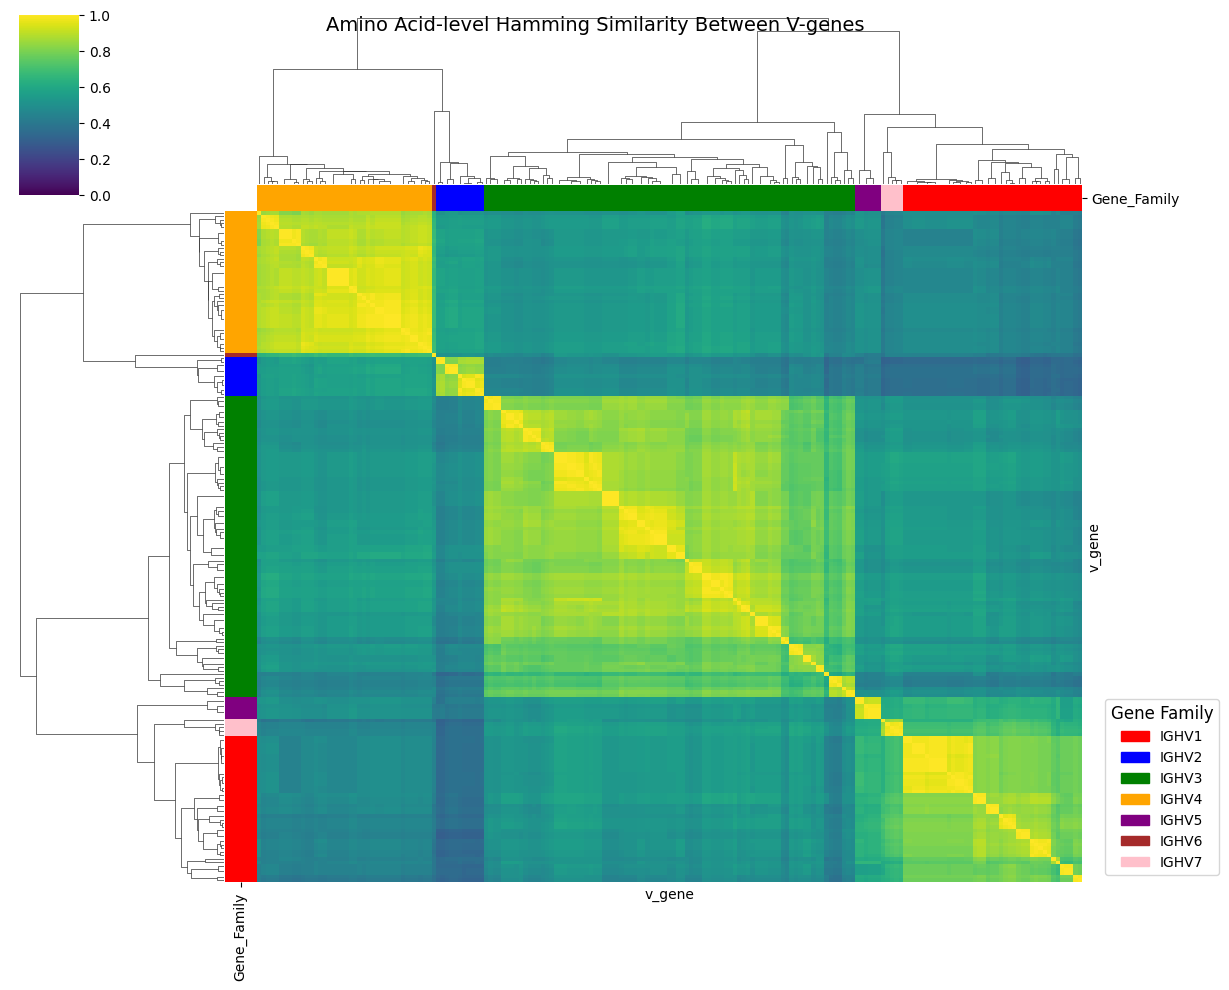

Gene family color mapping:
IGHV1: red
IGHV2: blue
IGHV3: green
IGHV4: orange
IGHV5: purple
IGHV6: brown
IGHV7: pink


/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


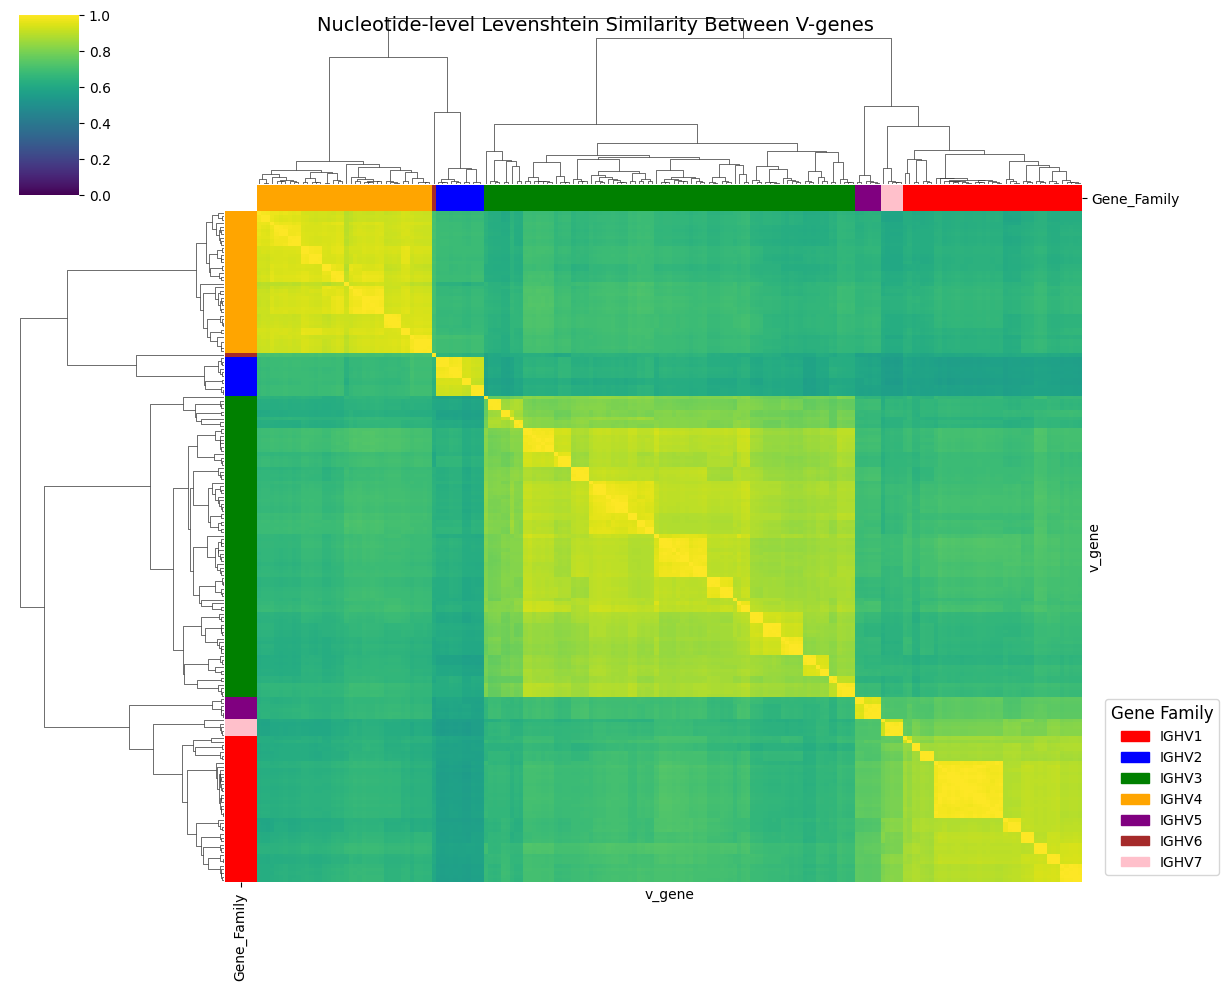

Gene family color mapping:
IGHV1: red
IGHV2: blue
IGHV3: green
IGHV4: orange
IGHV5: purple
IGHV6: brown
IGHV7: pink


/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


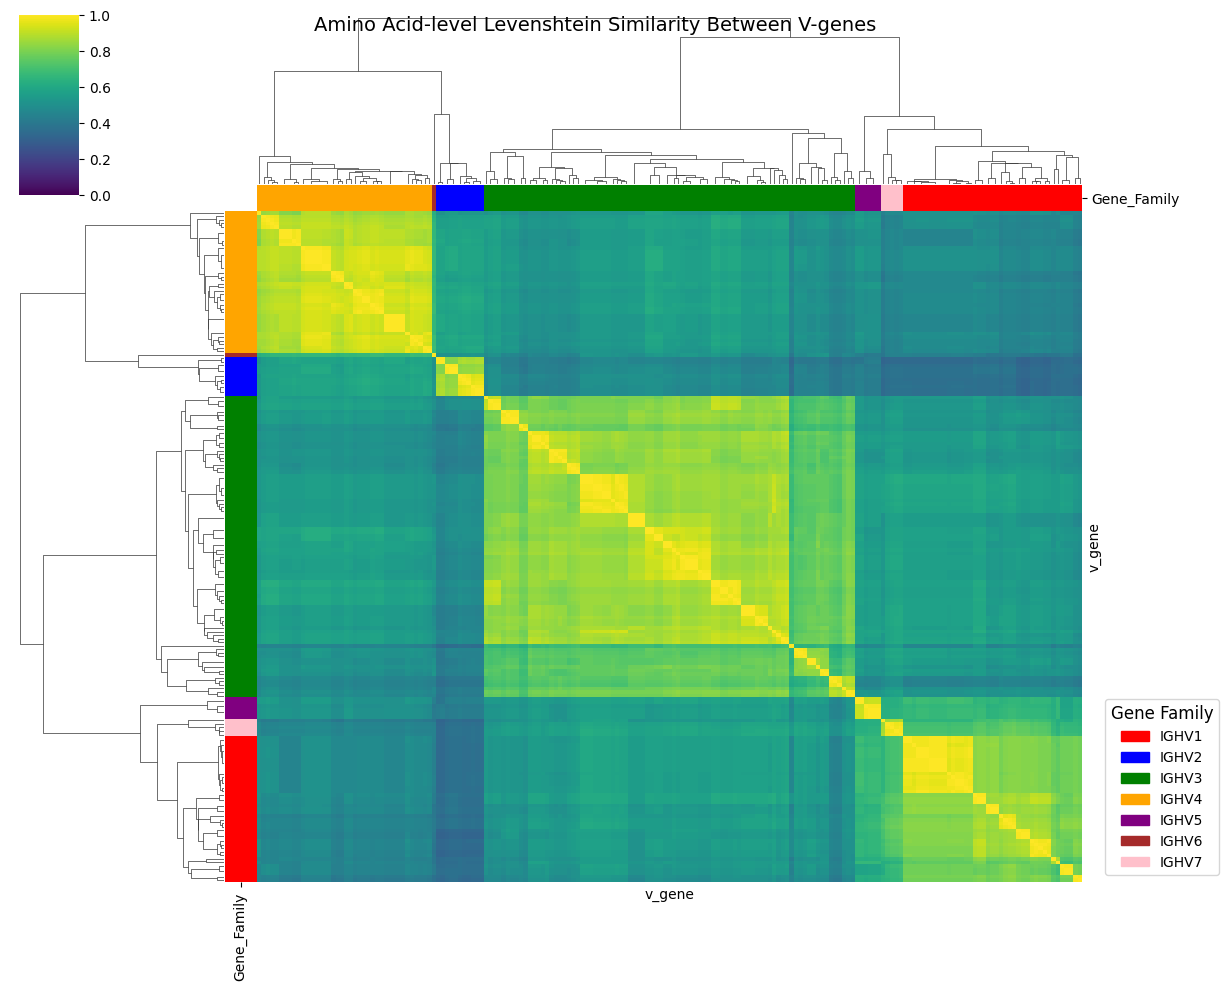

Gene family color mapping:
IGHV1: red
IGHV2: blue
IGHV3: green
IGHV4: orange
IGHV5: purple
IGHV6: brown
IGHV7: pink


In [8]:


def plot_similarity_clustermap(similarity_df, codons_df, title):
    """
    Plot a clustermap of gene similarity with gene family color bars.
    
    Args:
        similarity_df : DataFrame (square similarity matrix, index = v_genes)
        codons_df : DataFrame containing ['v_gene', 'v_family']
        title : str, title for the plot
    """
    
    # --- Gene family dictionary ---
    gene_family_dict = {i[1]: i[2] 
                        for i in list(codons_df[['v_gene', 'v_family']]
                                      .drop_duplicates().itertuples())}
    
    # Clean allele info (*01, *02, etc.)
    gene_family_dict_clean = {gene.split('*')[0]: family 
                              for gene, family in gene_family_dict.items()}
    
    # Unique families → assign colors
    unique_families = sorted(set(gene_family_dict_clean.values()))
    named_colors = ['red', 'blue', 'green', 'orange', 'purple', 
                    'brown', 'pink', 'gray', 'cyan', 'olive']
    category_colors_named = dict(zip(unique_families, 
                                     named_colors[:len(unique_families)]))
    
    # Cleaned gene names for mapping
    clean_index = [gene.split('*')[0] for gene in similarity_df.index]
    clean_columns = [gene.split('*')[0] for gene in similarity_df.columns]
    
    # Row & column colors
    row_colors_df = pd.DataFrame({
        'Gene_Family': pd.Series(clean_index, index=similarity_df.index)
                          .map(gene_family_dict_clean)
                          .map(category_colors_named)
    })
    col_colors_df = pd.DataFrame({
        'Gene_Family': pd.Series(clean_columns, index=similarity_df.columns)
                          .map(gene_family_dict_clean)
                          .map(category_colors_named)
    })
    
    # --- Clustermap ---
    g = sns.clustermap(similarity_df,
                       cmap='viridis',
                       square=True,
                       xticklabels=False,
                       yticklabels=False,
                       row_colors=row_colors_df,
                       col_colors=col_colors_df,
                       figsize=(12, 10),
                       vmin=0, vmax=1)
    
    # Title
    g.fig.suptitle(title, fontsize=14, y=0.98)
    
    # Legend for families
    legend_patches = [mpatches.Patch(color=color, label=family) 
                      for family, color in sorted(category_colors_named.items())]
    
    g.ax_heatmap.legend(handles=legend_patches,
                        bbox_to_anchor=(1.02, 0), 
                        loc='lower left',
                        title='Gene Family',
                        title_fontsize=12,
                        fontsize=10)
    
    plt.show()
    
    # Print mapping for reproducibility
    print("Gene family color mapping:")
    for family, color in sorted(category_colors_named.items()):
        print(f"{family}: {color}")

# --- Use it for your 4 similarity matrices ---
plot_similarity_clustermap(distance_hamming_nucleotide, codons_df, 
                           "Nucleotide-level Hamming Similarity Between V-genes")

plot_similarity_clustermap(distance_hamming_aa, codons_df, 
                           "Amino Acid-level Hamming Similarity Between V-genes")

plot_similarity_clustermap(distance_levenshtein_nucleotide, codons_df, 
                           "Nucleotide-level Levenshtein Similarity Between V-genes")

plot_similarity_clustermap(distance_levenshtein_aa, codons_df, 
                           "Amino Acid-level Levenshtein Similarity Between V-genes")


In [4]:

def plot_mirrored_vfamily_distribution(codons_df, v_family1, v_family2, figsize=(20, 4)):
    """
    Create a mirrored histogram showing amino acid distribution for two V families.
    v_family1 bars go above x-axis, v_family2 bars go below x-axis.
    
    Handles both integer sites (IMGT) and string sites with insertion codes (Chothia).
    Properly sorts sites to maintain biological ordering (e.g., 1, 1A, 2, 3, 3A, 4).
    """
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Filter data for each family
    family1_data = codons_df[codons_df.v_family == v_family1].copy()
    family2_data = codons_df[codons_df.v_family == v_family2].copy()
    
    # Get all unique sites and sort them properly
    all_sites = list(codons_df['site'].unique())
    all_sites_ordered = sort_antibody_sites(all_sites)
    
    # Create a mapping from site to integer position for plotting
    site_to_pos = {site: i for i, site in enumerate(all_sites_ordered)}
    positions = list(range(len(all_sites_ordered)))
    
    # Get all unique amino acids from both families
    all_amino_acids = sorted(set(family1_data['amino_acid'].unique()) | 
                           set(family2_data['amino_acid'].unique()))
    
    # Use tab20 colormap
    colors = plt.cm.tab20(np.linspace(0, 1, len(all_amino_acids)))
    color_map = dict(zip(all_amino_acids, colors))
    
    # Calculate counts for family1 (above x-axis)
    family1_counts = {aa: np.zeros(len(all_sites_ordered), dtype=float) for aa in all_amino_acids}
    family1_totals = np.zeros(len(all_sites_ordered), dtype=float)
    
    for aa in all_amino_acids:
        aa_data = family1_data[family1_data['amino_acid'] == aa]
        for _, row in aa_data.iterrows():
            if row['site'] in site_to_pos:
                pos = site_to_pos[row['site']]
                family1_counts[aa][pos] += 1
                family1_totals[pos] += 1
    
    # Convert to percentages
    for aa in all_amino_acids:
        family1_counts[aa] = np.divide(family1_counts[aa], family1_totals, 
                                     out=np.zeros_like(family1_counts[aa], dtype=float), 
                                     where=family1_totals!=0) * 100
    
    # Calculate counts for family2 (below x-axis)
    family2_counts = {aa: np.zeros(len(all_sites_ordered), dtype=float) for aa in all_amino_acids}
    family2_totals = np.zeros(len(all_sites_ordered), dtype=float)
    
    for aa in all_amino_acids:
        aa_data = family2_data[family2_data['amino_acid'] == aa]
        for _, row in aa_data.iterrows():
            if row['site'] in site_to_pos:
                pos = site_to_pos[row['site']]
                family2_counts[aa][pos] += 1
                family2_totals[pos] += 1
    
    # Convert to percentages and make negative
    for aa in all_amino_acids:
        family2_counts[aa] = -np.divide(family2_counts[aa], family2_totals, 
                                      out=np.zeros_like(family2_counts[aa], dtype=float), 
                                      where=family2_totals!=0) * 100
    
    # Plot both families
    # Plot family1 above x-axis (positive values) - stack them
    bottom1 = np.zeros(len(all_sites_ordered))
    for aa in all_amino_acids:
        if np.any(family1_counts[aa] > 0):
            ax.bar(positions, family1_counts[aa], bottom=bottom1, 
                  color=color_map[aa], alpha=0.8, width=0.8, 
                  edgecolor='black', linewidth=0.5)
            bottom1 += family1_counts[aa]
    
    # Plot family2 below x-axis (negative values) - stack them
    bottom2 = np.zeros(len(all_sites_ordered))
    for aa in all_amino_acids:
        if np.any(family2_counts[aa] < 0):
            ax.bar(positions, family2_counts[aa], bottom=bottom2, 
                  color=color_map[aa], alpha=0.8, width=0.8, 
                  edgecolor='black', linewidth=0.5)
            bottom2 += family2_counts[aa]
    
    # Customize the plot
    ax.set_xlabel('Site Position', fontsize=12)
    ax.set_ylabel(f'Percentage\n{v_family1} (above) | {v_family2} (below)', fontsize=12)
    ax.set_title(f'Amino Acid Distribution: {v_family1} vs {v_family2}', fontsize=14)
    ax.axhline(y=0, color='black', linestyle='-', alpha=0.8, linewidth=1)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Set x-axis ticks - show every 5th position with original site labels
    tick_positions = list(range(0, len(all_sites_ordered), 5))
    tick_labels = [str(all_sites_ordered[i]) for i in tick_positions]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=90)
    
    # Create legend for amino acids
    legend_handles = []
    legend_labels = []
    for aa in all_amino_acids:
        legend_handles.append(plt.Rectangle((0,0),1,1, facecolor=color_map[aa], 
                                          edgecolor='black', linewidth=0.5, alpha=0.8))
        legend_labels.append(aa)
    
    ax.legend(legend_handles, legend_labels, bbox_to_anchor=(1.05, 1), loc='upper left', 
              title='Amino Acids')
    
    plt.tight_layout()
    plt.show()
    
    return fig, ax

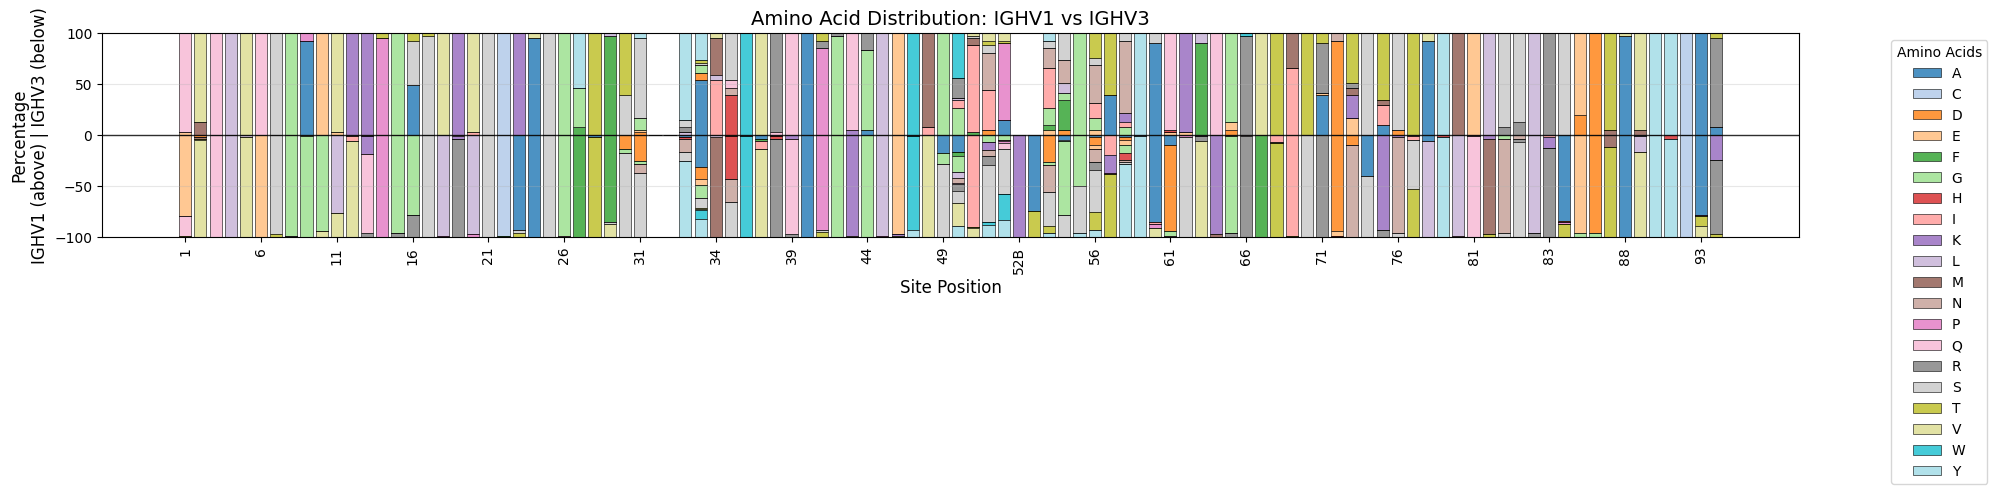

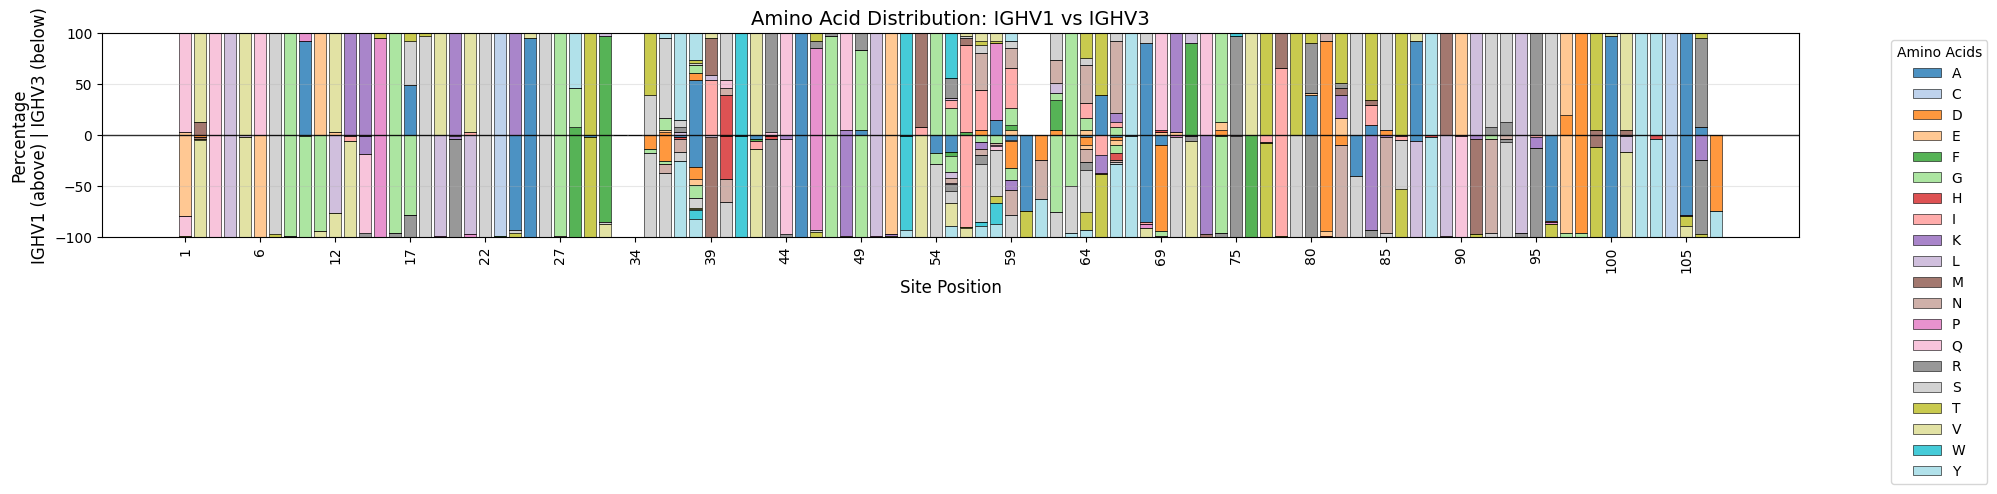

In [5]:
codons_df_chothia = pd.read_csv(localify(f"germline/germline_codons_chothia.csv"))

fig, ax = plot_mirrored_vfamily_distribution(codons_df_chothia, 'IGHV1', 'IGHV3')
#fig, ax = plot_mirrored_vfamily_distribution(codons_df_chothia, 'IGHV3', 'IGHV4')


codons_df_imgt = pd.read_csv(localify(f"germline/germline_codons_imgt.csv"))

fig, ax = plot_mirrored_vfamily_distribution(codons_df_imgt, 'IGHV1', 'IGHV3')
#fig, ax = plot_mirrored_vfamily_distribution(codons_df_imgt, 'IGHV3', 'IGHV4')